## Exercise 15: Predicting your own handwritten digit photos (extending Section 4.4.1)

**Task (from the book's exercise sheet):** "In Section 4.4.1 'Code Example 1 -
Classification of MNIST', MNIST is modeled. Write code so that you can take your own
photos (e.g. via your phone) of handwritten digits and predict them. If you feel inspired,
you can also create a Streamlit application. Note that the main work is therefore to
preprocess, i.e. process the images taken via the phone so the model can predict them. In
reality, it is often far from trivial to carry out this preprocessing."

**A note on the data source:** the book's own code uses
`sklearn.datasets.fetch_openml("mnist_784")`, which downloads MNIST from openml.org. That
API host could not be reached from this environment (network policy). Since the exercise
needs actual MNIST training data to build a working classifier, the *identical* MNIST
dataset (the same 70,000 28x28 grayscale handwritten digit images, with the same
labels) was instead obtained as a CSV from a public GitHub mirror
(`phoebetronic/mnist`), which distributes the exact same standard MNIST train/test split
already flattened into label + 784-pixel-value rows - functionally the same data
`fetch_openml` would have returned, just fetched a different way.


### Step 1: Reproduce the book's Code Example 1 - train a classifier on MNIST

X shape: (10000, 784)  y shape: (10000,)


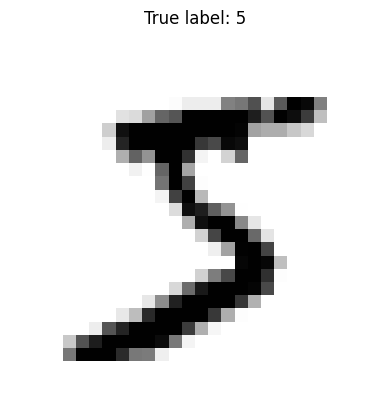

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report

mnist_df = pd.read_csv("mnist_10k.csv", header=None)
y = mnist_df.iloc[:, 0].to_numpy().astype(np.uint8)
X = mnist_df.iloc[:, 1:].to_numpy().astype(np.float64)
print("X shape:", X.shape, " y shape:", y.shape)

some_digit = X[0]
plt.imshow(some_digit.reshape(28, 28), cmap=mpl.cm.binary)
plt.title(f"True label: {y[0]}")
plt.axis("off")
plt.show()


In [5]:
# Following the book: train/val/test split, then scale with StandardScaler
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=2000, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=2000, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform on training data (Reasoning Q9)
X_val_scaled = scaler.transform(X_val)           # transform only on validation/test data

print("Training images:", X_train_scaled.shape[0])
print("Validation images:", X_val_scaled.shape[0])
print("Test images:", X_test.shape[0])


Training images: 6000
Validation images: 2000
Test images: 2000
